# Attack Efficiency Analysis (NeuralHash)

This notebook loads the long-format CSV logs and produces:
- Distance vs Steps (median + IQR)
- Distance vs Time (median + IQR)
- Success Rate vs Steps/Time
- Time-to-success summary table


In [1]:
import os, sys

# IF currently inside: <repo>/fdeph_eval/analysis
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Repo root:", REPO_ROOT)

Repo root: /home/exouser/ar-sec-eval


In [2]:
import os
import pandas as pd

from fdeph_eval.analysis.plotting import (
    load_attack_csv,
    summarize_run,
    plot_distance_vs_steps,
    plot_distance_vs_time,
    plot_success_rate_vs_steps,
    plot_success_rate_vs_time,
    export_time_to_success_table,
)

LOG_PATH = os.path.join(REPO_ROOT, "logs", "attack_steps_nhash_evasion_mt500.csv")
FIG_DIR = os.path.join(REPO_ROOT, "fdeph_eval", "analysis", "figures")
TABLE_DIR = os.path.join(REPO_ROOT, "fdeph_eval", "analysis", "tables")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

print("LOG_PATH:", LOG_PATH)
print("FIG_DIR:", FIG_DIR)
print("TABLE_DIR:", TABLE_DIR)

LOG_PATH: /home/exouser/ar-sec-eval/logs/attack_steps_nhash_evasion_mt500.csv
FIG_DIR: /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures
TABLE_DIR: /home/exouser/ar-sec-eval/fdeph_eval/analysis/tables


In [3]:
df = load_attack_csv(LOG_PATH)
df.head()

,image_id,hash_method,attack_type,step,elapsed_ms,dist_raw,dist_norm,l2,linf,ssim,success,source_path
1,ILSVRC2012_val_00003351__a4591751d1,nhash,evasion,1,0.001,0.0,0.0,0.0,0.0,0.0,0,./inputs/inputs_500/ILSVRC2012_val_00003351__a...
2,ILSVRC2012_val_00003620__a6e4864228,nhash,evasion,1,0.001,0.0,0.0,0.0,0.0,0.0,0,./inputs/inputs_500/ILSVRC2012_val_00003620__a...
3,ILSVRC2012_val_00014381__cdfef1d2c9,nhash,evasion,1,0.000,0.0,0.0,0.0,0.0,0.0,0,./inputs/inputs_500/ILSVRC2012_val_00014381__c...
4,ILSVRC2012_val_00009111__afa522e7eb,nhash,evasion,1,0.000,0.0,0.0,0.0,0.0,0.0,0,./inputs/inputs_500/ILSVRC2012_val_00009111__a...
5,ILSVRC2012_val_00003351__a4591751d1,nhash,evasion,2,276.762,0.0,0.0,0.0,0.0,0.0,0,./inputs/inputs_500/ILSVRC2012_val_00003351__a...


In [4]:
from fdeph_eval.analysis.plotting import time_to_success_stats, plot_time_to_success_hist

In [5]:
summary = summarize_run(df)
summary

RunSummary(n_images=500, n_succeeded=500, success_rate=1.0, median_steps_to_success=37.0, median_time_ms_to_success=5900.4805)

## Distance vs Steps

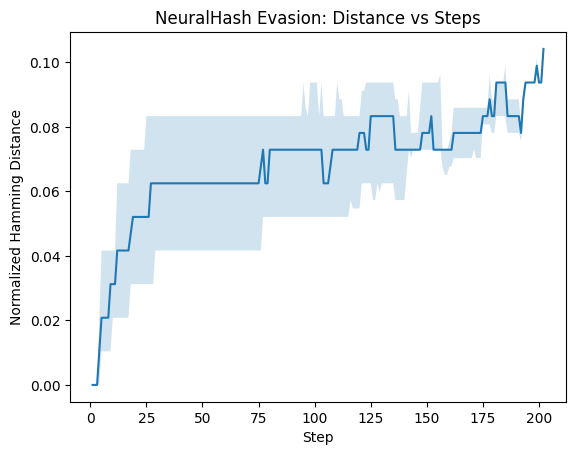

In [13]:
plot_distance_vs_steps(
    df,
    out_path=f"{FIG_DIR}/nhash_distance_vs_steps.png",
    title="NeuralHash Evasion: Distance vs Steps"
)


## Distance vs Time

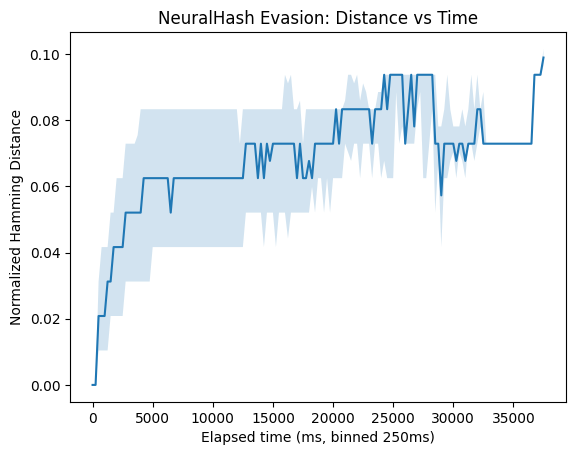

In [14]:
plot_distance_vs_time(
    df,
    bin_ms=250,
    out_path=f"{FIG_DIR}/nhash_distance_vs_time.png",
    title="NeuralHash Evasion: Distance vs Time"
)


## Success Rate vs Steps

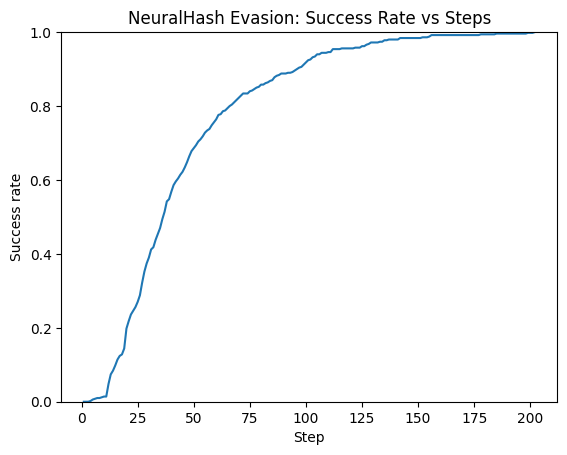

In [15]:
plot_success_rate_vs_steps(
    df,
    out_path=f"{FIG_DIR}/nhash_success_rate_vs_steps.png",
    title="NeuralHash Evasion: Success Rate vs Steps"
)


## Success Rate vs Time

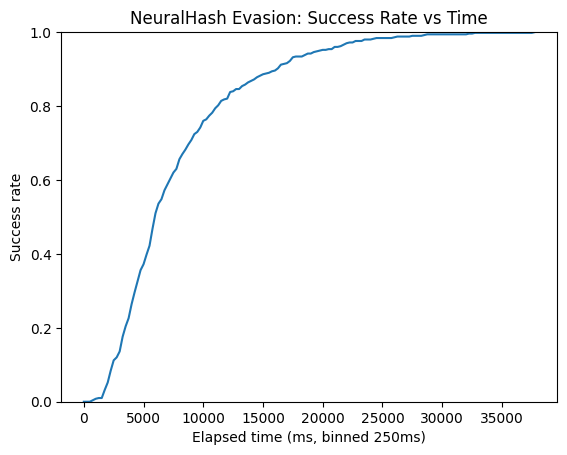

In [16]:
plot_success_rate_vs_time(
    df,
    bin_ms=250,
    out_path=f"{FIG_DIR}/nhash_success_rate_vs_time.png",
    title="NeuralHash Evasion: Success Rate vs Time"
)


## Time-to-success table

In [6]:
events = export_time_to_success_table(df, f"{TABLE_DIR}/nhash_time_to_success.csv")
events.head()

,image_id,success_step,success_elapsed_ms
0,ILSVRC2012_val_00003351__a4591751d1,37,6579.729
1,ILSVRC2012_val_00003620__a6e4864228,42,9669.798
2,ILSVRC2012_val_00009111__afa522e7eb,48,11051.095
3,ILSVRC2012_val_00014381__cdfef1d2c9,110,23483.386
4,ILSVRC2012_val_00022792__914a966190,28,3740.803


## Time-to-success Histogram

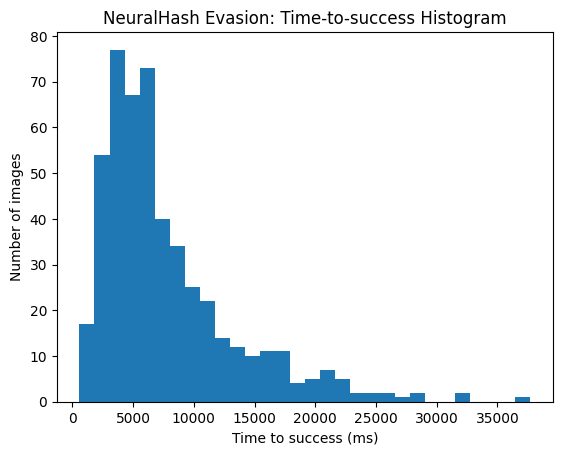

In [7]:
plot_time_to_success_hist(
    df,
    out_path=f"{FIG_DIR}/nhash_time_to_success_hist.png",
    title="NeuralHash Evasion: Time-to-success Histogram"
)

## Median + P95 table

In [8]:
stats = time_to_success_stats(df)
stats

,n_images,n_succeeded,success_rate,median_steps,p95_steps,median_time_ms,p95_time_ms
0,500,500,1.0,37.0,112.0,5900.4805,19544.64995


In [9]:
stats.to_csv(f"{TABLE_DIR}/nhash_summary_stats.csv", index=False)

## Threshold sweep analysis (compare T=0.08/0.10/0.12)

In [10]:
import pandas as pd
from fdeph_eval.analysis.plotting import load_attack_csv, time_to_success_stats

paths = {
    "T0.08": os.path.join(REPO_ROOT, "logs", "attack_steps_nhash_evasion_mt500_T0.08.csv"),
    "T0.10": os.path.join(REPO_ROOT, "logs", "attack_steps_nhash_evasion_mt500_T0.10.csv"),
    "T0.12": os.path.join(REPO_ROOT, "logs", "attack_steps_nhash_evasion_mt500_T0.12.csv"),
}

rows = []
for label, p in paths.items():
    d = load_attack_csv(p)
    r = time_to_success_stats(d)
    r.insert(0, "threshold", label)
    rows.append(r)

sweep = pd.concat(rows, ignore_index=True)
sweep

,threshold,n_images,n_succeeded,success_rate,median_steps,p95_steps,median_time_ms,p95_time_ms
0,T0.08,500,500,1.0,28.0,99.0,4644.9965,16540.07220
1,T0.10,500,500,1.0,37.0,112.0,5877.9705,19032.44595
2,T0.12,500,500,1.0,44.0,130.0,7053.3145,21183.58530


In [12]:
sweep.to_csv(f"{TABLE_DIR}/nhash_threshold_sweep.csv", index=False)